![Image](img/dataset-diagram-logo.png)


**Objectif** : xarray c'est comme pandas pour le côté "labellisations" mais **ndim** -> nombre de dimensions illimité
- On n'appelle plus cela des DataFrame mais des DataArray (qui peuvent être rangés dans des Dataset)
- Ca permet de ranger rigoureseument ses données ...
- ... et de faire des opérations et/ou des figures de manière très facile et explicite

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

##  Initialiser un DataArray

In [2]:
truc = xr.DataArray(np.random.randint(2, 3))
truc

<xarray.DataArray ()> Size: 8B
array(2)

In [3]:
da = xr.DataArray(data = np.random.randint(10, size=(2, 3)), dims=('x', 'y'), coords={'x': ['a', 'b'], 'y':['A','B','C']}, attrs = {'units':'test'})
da

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[4, 9, 6],
       [4, 9, 6]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:    test

## Attribute of DataArray

In [4]:
print('values : ', da.values)
print('dims : ', da.dims)
print('coords : ', da.coords)
print('attrs metadata', da.attrs)

values :  [[4 9 6]
 [4 9 6]]
dims :  ('x', 'y')
coords :  Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
attrs metadata {'units': 'test'}


## Indexing

### numpy like

In [5]:
da[:, :2]

<xarray.DataArray (x: 2, y: 2)> Size: 32B
array([[4, 9],
       [4, 9]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 8B 'A' 'B'
Attributes:
    units:    test

### pandas like with loc[]

In [6]:
da.loc[['a', 'b'], :]

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[4, 9, 6],
       [4, 9, 6]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:    test

### with isel()

In [7]:
da.isel(y=[0, 2])

<xarray.DataArray (x: 2, y: 2)> Size: 32B
array([[4, 6],
       [4, 6]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 8B 'A' 'C'
Attributes:
    units:    test

### with sel()

In [8]:
da.sel(x=['a'])

<xarray.DataArray (x: 1, y: 3)> Size: 24B
array([[4, 9, 6]])
Coordinates:
  * x        (x) <U1 4B 'a'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:    test

## Attributes (metadata) useful for plotting

In [9]:
da.attrs['long_name'] = 'random useless stuff'
da.attrs['units'] = 'mV'
da

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[4, 9, 6],
       [4, 9, 6]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:      mV
    long_name:  random useless stuff

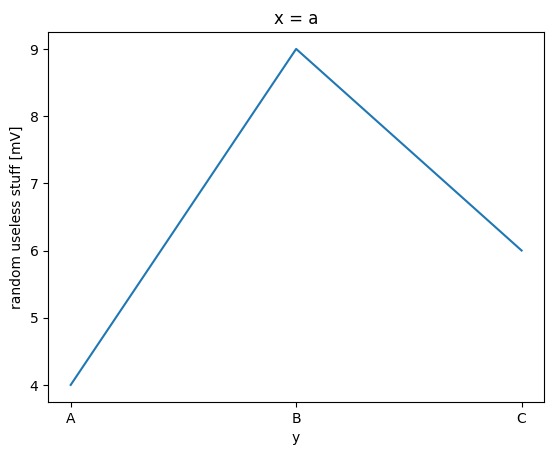

In [10]:
da.sel(x='a').plot()

## Computation / aggregation

In [11]:
# mais on peut utiliser les noms des axes au lieu de leur numéro
da.mean(dim='y')

<xarray.DataArray (x: 2)> Size: 16B
array([6.33333333, 6.33333333])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
Attributes:
    units:      mV
    long_name:  random useless stuff

## GroupBy

In [12]:
da

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[4, 9, 6],
       [4, 9, 6]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:      mV
    long_name:  random useless stuff

In [13]:
labels = xr.DataArray(data = ['E', 'F', 'E'], coords = [da.coords['y']], name='labels')
labels

<xarray.DataArray 'labels' (y: 3)> Size: 12B
array(['E', 'F', 'E'], dtype='<U1')
Coordinates:
  * y        (y) <U1 12B 'A' 'B' 'C'

In [14]:
da1 = da.groupby(labels).sum('y')
da1

<xarray.DataArray (x: 2, labels: 2)> Size: 32B
array([[10,  9],
       [10,  9]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * labels   (labels) object 16B 'E' 'F'
Attributes:
    units:      mV
    long_name:  random useless stuff

In [15]:
da2 = da.groupby(labels).apply(lambda x: x - x.min())
da2

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[0, 0, 2],
       [0, 0, 2]])
Coordinates:
  * x        (x) <U1 8B 'a' 'b'
  * y        (y) <U1 12B 'A' 'B' 'C'
Attributes:
    units:      mV
    long_name:  random useless stuff

## Pandas

In [16]:
series = da.to_series()
series

x  y
a  A    4
   B    9
   C    6
b  A    4
   B    9
   C    6
dtype: int64

In [17]:
series.to_xarray()

<xarray.DataArray (x: 2, y: 3)> Size: 48B
array([[4, 9, 6],
       [4, 9, 6]])
Coordinates:
  * x        (x) object 16B 'a' 'b'
  * y        (y) object 24B 'A' 'B' 'C'

## Dataset = DataArrays in the same place

In [20]:
times = np.arange(0, 10, 0.01)
freqs = np.arange(10, 50, 2.)

da1 = xr.DataArray(np.random.randn(times.size),
                     coords={'times': times},
                     dims=('times'))

da2 = xr.DataArray(np.random.randn(times.size, freqs.size),
                     coords={'times': times, 'freqs': freqs},
                     dims=('times', 'freqs'))



ds = xr.Dataset({'raw_signal': da1,
                 'time_freq' : da2,
                 'one_scalar': np.pi})
ds

<xarray.Dataset> Size: 176kB
Dimensions:     (times: 1000, freqs: 20)
Coordinates:
  * times       (times) float64 8kB 0.0 0.01 0.02 0.03 ... 9.96 9.97 9.98 9.99
  * freqs       (freqs) float64 160B 10.0 12.0 14.0 16.0 ... 42.0 44.0 46.0 48.0
Data variables:
    raw_signal  (times) float64 8kB 0.9979 -0.74 2.078 ... -1.26 -0.474 -1.705
    time_freq   (times, freqs) float64 160kB 1.11 -1.802 ... -0.01239 -1.419
    one_scalar  float64 8B 3.142

In [21]:
ds['raw_signal']

<xarray.DataArray 'raw_signal' (times: 1000)> Size: 8kB
array([ 9.97852104e-01, -7.40044151e-01,  2.07785242e+00, -5.97380611e-02,
       -1.10457795e+00,  4.99487623e-01, -3.76033111e-01,  7.99870978e-02,
       -1.53148615e+00, -2.80301128e-01,  7.12390600e-01,  9.83003380e-01,
       -5.10498385e-02, -6.86500605e-01,  7.91431984e-01, -5.27653768e-02,
        1.58220080e-01,  3.34149807e-01,  1.23219161e+00, -8.70644004e-01,
       -8.22627049e-01,  1.28365843e-01,  8.52729197e-01,  2.98985617e-01,
       -6.88597469e-01,  1.31821173e+00,  1.34153587e+00, -1.86224134e+00,
        1.41661077e+00, -1.71874198e-01, -5.73922564e-01, -5.38551662e-01,
       -4.13961796e-01, -7.52976488e-01,  8.19708830e-01, -7.66902703e-01,
        5.10725459e-01, -5.89941056e-02,  6.74529452e-02,  6.45365493e-01,
        1.02418566e+00, -1.00080105e-01,  8.82207941e-01, -1.35561796e+00,
        2.34532093e+00, -2.60177445e-01, -2.49469675e-01,  7.15493598e-01,
        4.17603935e-01, -1.04680505e+00,  2.26428126e+00,  1.63295444e-01,
       -2.13771970e-01,  3.22140911e+00,  3.74401580e-01,  6.60060552e-01,
       -1.59896091e-01,  4.74044970e-01, -9.70524400e-01, -8.36718233e-01,
       -5.76576490e-02,  2.94314946e-01, -2.50403048e-01,  5.39219256e-01,
       -2.16059221e+00, -1.16944519e-01, -2.45922534e+00, -1.65999631e+00,
       -5.55270039e-01,  9.36399646e-01, -7.87118014e-01,  3.33320684e-01,
        1.04252828e+00,  1.10974254e+00, -1.35847055e+00,  4.25490728e-01,
        9.96648730e-01,  1.03864417e+00,  1.49066498e+00,  4.63744537e-01,
...
       -7.80722191e-01,  1.00660874e+00,  8.57360847e-01, -2.24863377e+00,
        6.87338174e-01, -7.33540977e-01,  1.45427497e+00,  1.34492834e+00,
       -1.62838746e-02,  5.16898891e-01, -1.38573043e-01, -5.80034870e-02,
        1.21408786e-01,  8.57297889e-02,  8.76558555e-02,  1.86149759e-02,
        5.64394865e-01,  9.06419337e-01, -2.87100730e-01, -4.23234601e-02,
       -2.24511626e-01,  1.99287049e-01,  5.79174989e-01,  1.99954948e-01,
       -2.50032386e-01,  6.40639866e-01,  9.33877896e-01, -6.89434980e-01,
       -1.74991913e+00,  8.78910264e-01,  7.68456298e-01, -2.53059556e+00,
        1.12090491e+00,  7.94038183e-01,  1.74106696e+00, -4.54222663e-01,
        4.66599966e-01, -3.19945165e-01,  5.26114812e-01,  8.58752214e-01,
        1.28685927e+00, -3.49459152e-01,  1.31229061e+00, -2.62064010e-01,
        3.23191729e-01,  6.70046522e-01,  5.12281142e-01,  1.14858307e+00,
        1.34963109e+00, -1.21268589e-01,  2.56941135e-02, -1.00072082e+00,
       -1.76887138e+00, -1.08930931e-01,  1.85779633e+00, -5.48525392e-01,
       -2.84939581e-01,  2.47588577e-01, -9.05604787e-01,  1.86294680e+00,
        1.54377011e-01,  8.61962809e-01, -7.70834576e-01, -4.56567578e-03,
       -8.54312148e-01,  2.01489309e+00,  1.08814424e+00, -7.65426938e-01,
       -3.86537683e-01, -8.49625203e-01, -4.22740270e-02,  6.98518536e-01,
        1.10011673e+00,  1.17554955e+00, -4.99335531e-01,  5.53180515e-03,
       -8.38300936e-01, -1.26008452e+00, -4.74022488e-01, -1.70535251e+00])
Coordinates:
  * times    (times) float64 8kB 0.0 0.01 0.02 0.03 0.04 ... 9.96 9.97 9.98 9.99

In [22]:
ds.isel(times=slice(0,100))

<xarray.Dataset> Size: 18kB
Dimensions:     (times: 100, freqs: 20)
Coordinates:
  * times       (times) float64 800B 0.0 0.01 0.02 0.03 ... 0.96 0.97 0.98 0.99
  * freqs       (freqs) float64 160B 10.0 12.0 14.0 16.0 ... 42.0 44.0 46.0 48.0
Data variables:
    raw_signal  (times) float64 800B 0.9979 -0.74 2.078 ... 1.974 -1.46 -0.05012
    time_freq   (times, freqs) float64 16kB 1.11 -1.802 -1.091 ... 0.586 -0.8737
    one_scalar  float64 8B 3.142

## Plotting with xarray

### Plot 1D

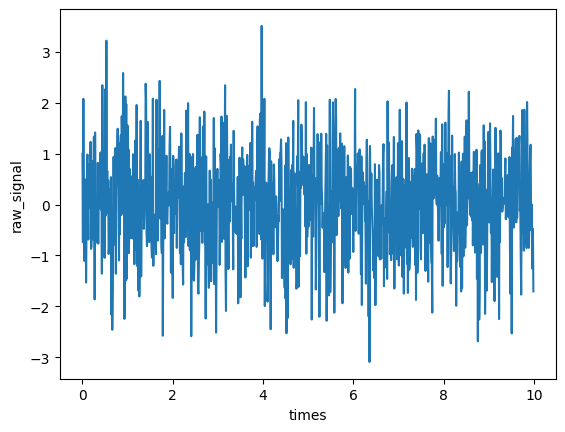

In [23]:
ds['raw_signal'].plot()

### Plot 2D

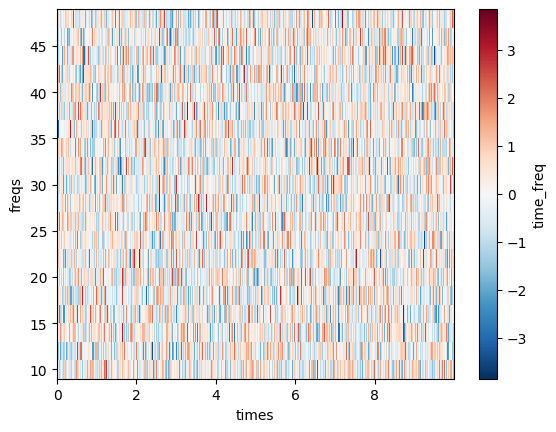

In [24]:
ds['time_freq'].plot(x = 'times', y = 'freqs') # xarray choisit automatiquement la bonne méthode ici

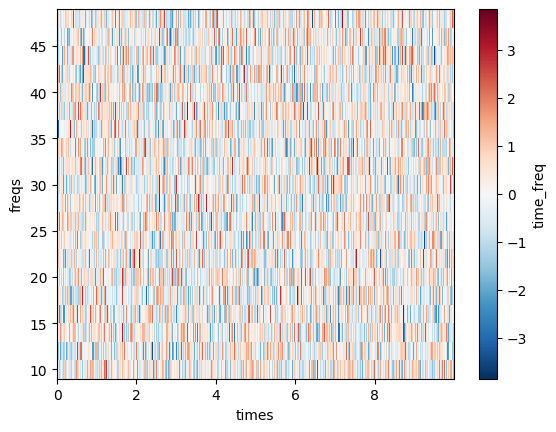

In [25]:
ds['time_freq'].plot.pcolormesh(x = 'times', y = 'freqs') # ici on demande explicitement un pcolormesh

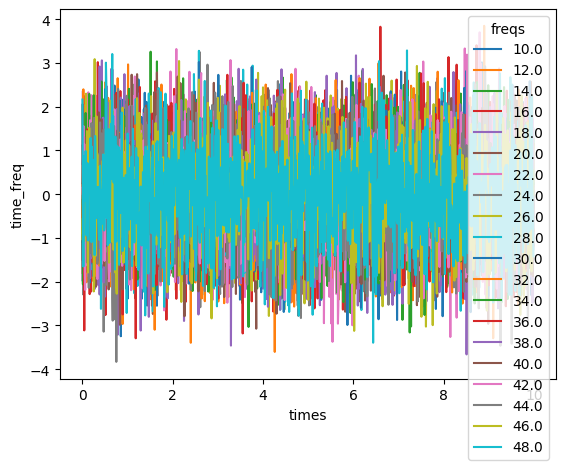

In [27]:
_ = ds['time_freq'].plot.line(x = 'times', hue = 'freqs') # alors que ici on demande un plot.line avec une superposition (hue)

## NetCDF (xarray format based on HDF5)

In [28]:
ds.to_netcdf('example.nc')

In [29]:
xr.open_dataset('example.nc')

<xarray.Dataset> Size: 176kB
Dimensions:     (times: 1000, freqs: 20)
Coordinates:
  * times       (times) float64 8kB 0.0 0.01 0.02 0.03 ... 9.96 9.97 9.98 9.99
  * freqs       (freqs) float64 160B 10.0 12.0 14.0 16.0 ... 42.0 44.0 46.0 48.0
Data variables:
    raw_signal  (times) float64 8kB ...
    time_freq   (times, freqs) float64 160kB ...
    one_scalar  float64 8B ...

## zarr (xarray format based on zarr)

In [30]:
ds.to_zarr('example.zarr')

/home/samuel/.virtualenvs/env_formation/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [31]:
xr.open_dataset('example.zarr')

<xarray.Dataset> Size: 176kB
Dimensions:     (times: 1000, freqs: 20)
Coordinates:
  * times       (times) float64 8kB 0.0 0.01 0.02 0.03 ... 9.96 9.97 9.98 9.99
  * freqs       (freqs) float64 160B 10.0 12.0 14.0 16.0 ... 42.0 44.0 46.0 48.0
Data variables:
    one_scalar  float64 8B ...
    raw_signal  (times) float64 8kB ...
    time_freq   (times, freqs) float64 160kB ...

## Exercice 1

 * Explorer le dossier `data/data_folder`
 * Créer un DataSet/DataArray pour organiser les datas de manière multi-dimensionelle
 
 Chaque tableau `*.npy` a pour shape `(4, 3)`
 On peut considerer ces dimensions comme `(trial, question)` avec trial allant de 1 à 4 et question étant 'a', 'b', 'c'

## Solution 1

In [34]:
subjects = ['HJ02','LM04','ST01','UJ03']
sessions = ['session_1','session_2','session_3','session_4','session_5']
trials = [1, 2 ,3 ,4]
questions = ['a','b','c']

In [35]:
sub = 'LM04'
ses = 'session_1'
data_sub_ses = np.load(f'./data/data_folder/{sub}/{ses}.npy')
data_sub_ses

array([[-0.38437686, -0.06271837, -0.82084786],
       [-0.79739786,  0.83418151,  0.07146799],
       [ 0.13707849,  0.11063433,  0.2016983 ],
       [-0.57891268, -0.52524443,  0.329934  ]])

In [36]:
data_shape = (len(subjects), len(sessions), len(trials), len(questions))
da = xr.DataArray(data = np.zeros(data_shape),
                  dims = ['subject','session','trial','question'],
                  coords = {'subject':subjects,'session':sessions, 'trial':trials , 'question':questions})

for subject in subjects:
    for session in sessions:
        da.loc[subject,session,:,:] = np.load(f'./data/data_folder/{subject}/{session}.npy')

In [37]:
da

<xarray.DataArray (subject: 4, session: 5, trial: 4, question: 3)> Size: 2kB
array([[[[ 0.55996076,  1.40188671,  2.00716549],
         [ 0.39095788,  0.77321955, -0.75044337],
         [ 1.00866443, -0.35668001,  0.49793207],
         [-0.86711327,  0.40056226, -0.77971829]],

        [[-1.29806685,  0.03022072, -1.37587918],
         [ 0.57163766,  1.03226634,  0.37189735],
         [-0.7952975 , -0.34279625,  0.37093617],
         [ 0.44633999, -0.44482825,  1.13871228]],

        [[-1.48598199, -1.45692286,  1.90019572],
         [-1.31145154, -0.11440697, -1.83359649],
         [ 1.27752558,  0.3734068 , -0.55602085],
         [-1.55311024,  0.93572405,  1.326925  ]],

        [[-1.56899284,  1.10091972, -1.04331003],
         [-1.20840134, -0.17228726,  1.34375573],
         [ 0.1379342 , -1.13626238,  0.22276613],
         [ 0.42508644,  0.58950312,  0.35705745]],

...

        [[ 0.39786945,  0.61703221,  0.15183394],
         [-0.43560855, -0.35867696,  1.34792642],
         [ 1.2627654 , -1.01953818,  1.44585437],
         [ 0.89007494,  0.61240892,  0.02416696]],

        [[ 2.52932469,  1.68744126,  1.94924154],
         [ 0.86571286,  0.87198381,  0.18029687],
         [ 2.25554749, -1.07055761, -0.48938934],
         [ 1.7422904 , -0.10962135,  1.14372104]],

        [[ 1.58631923, -0.72739628, -0.26158817],
         [ 2.56425695,  1.13199062,  0.54568674],
         [-0.49778992,  1.4074506 , -0.4162464 ],
         [ 1.55625927,  0.60217849,  0.3552943 ]],

        [[-1.45133283, -1.40125602, -1.99980305],
         [ 0.10602695,  0.43662809, -0.22712406],
         [ 0.52926951,  0.56603048, -1.72214415],
         [-0.67931098,  0.42050995,  0.09543247]]]])
Coordinates:
  * subject   (subject) <U4 64B 'HJ02' 'LM04' 'ST01' 'UJ03'
  * session   (session) <U9 180B 'session_1' 'session_2' ... 'session_5'
  * trial     (trial) int64 32B 1 2 3 4
  * question  (question) <U1 12B 'a' 'b' 'c'

## Exercice 2

 * Localiser les réponses aux questions du sujet HJ02 durant sa première session et suite au premier trial

## Solution 2

In [38]:
da.loc['HJ02','session_1',1,:]

<xarray.DataArray (question: 3)> Size: 24B
array([0.55996076, 1.40188671, 2.00716549])
Coordinates:
  * question  (question) <U1 12B 'a' 'b' 'c'
    subject   <U4 16B 'HJ02'
    session   <U9 36B 'session_1'
    trial     int64 8B 1

## Exercice 3

 * Trouver une façon intelligente de faire un plot représentant toutes les informations sur une seule figure

## Solution 3

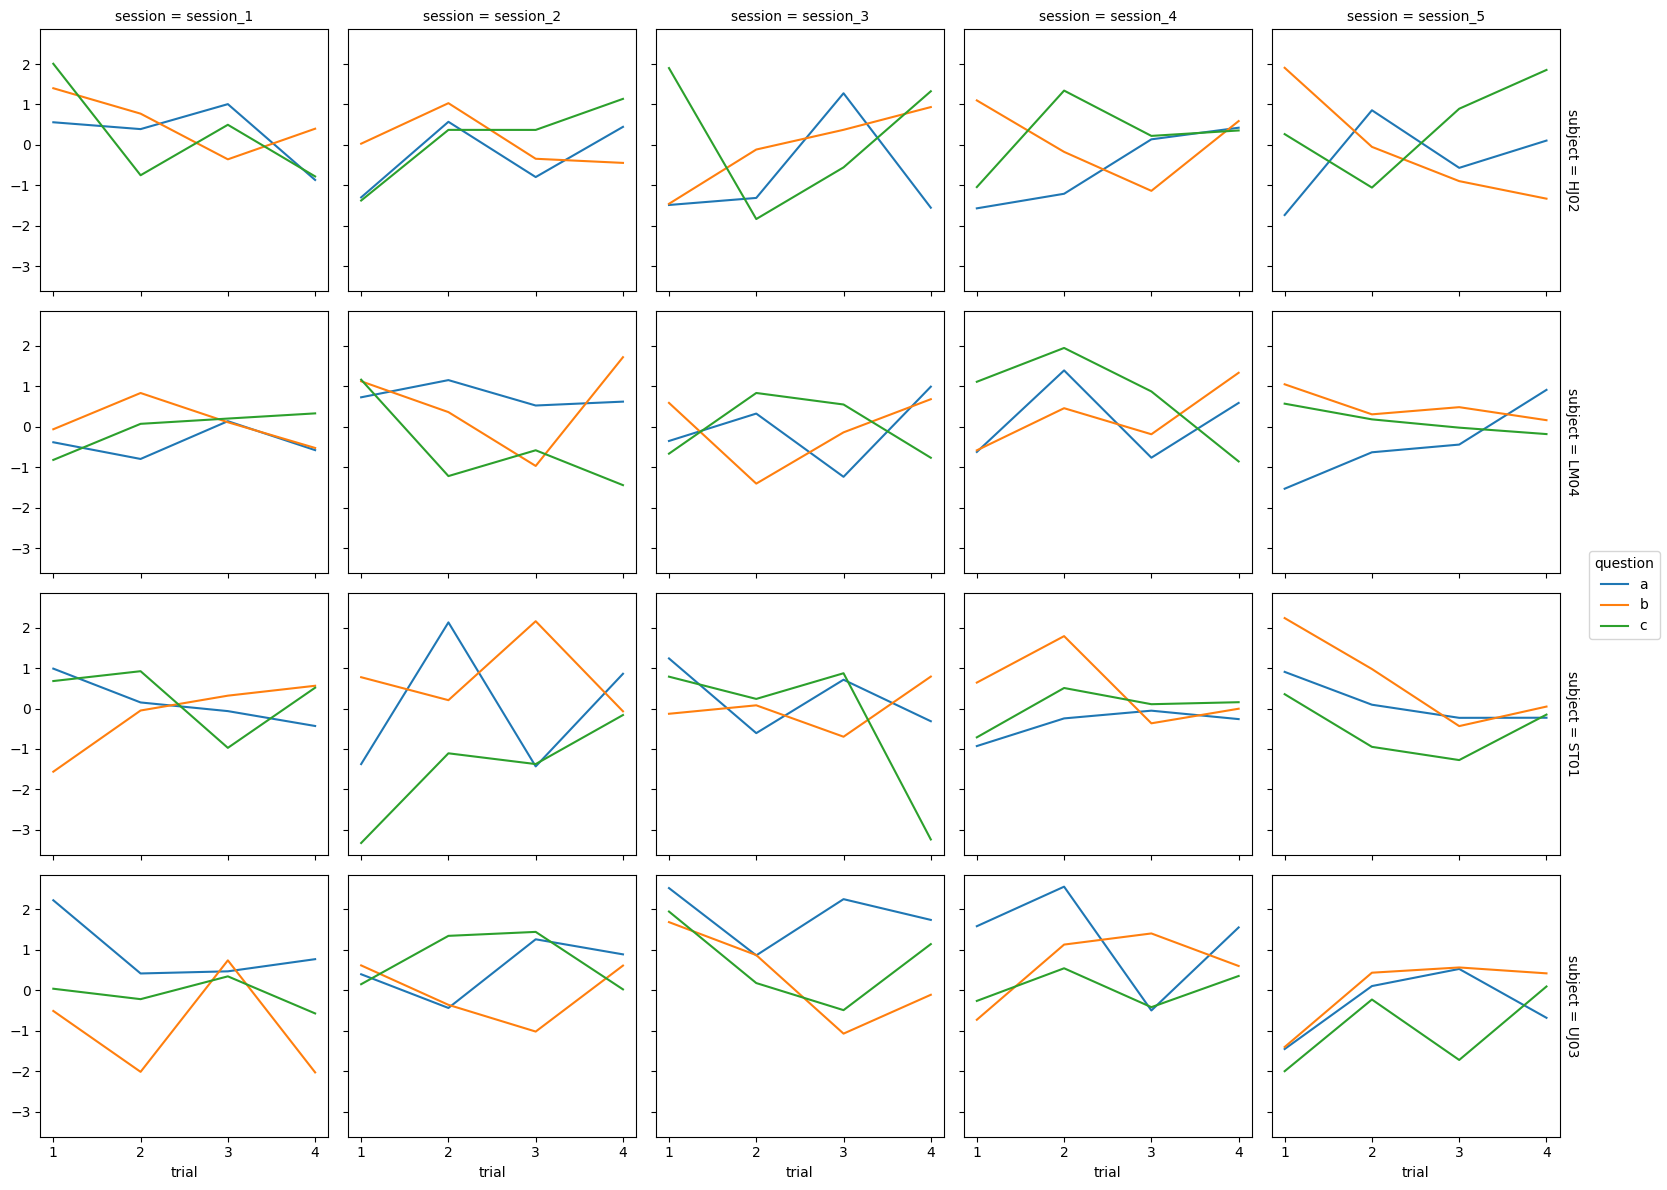

In [40]:
da.plot.line(x = 'trial', hue = 'question', col = 'session', row = 'subject')